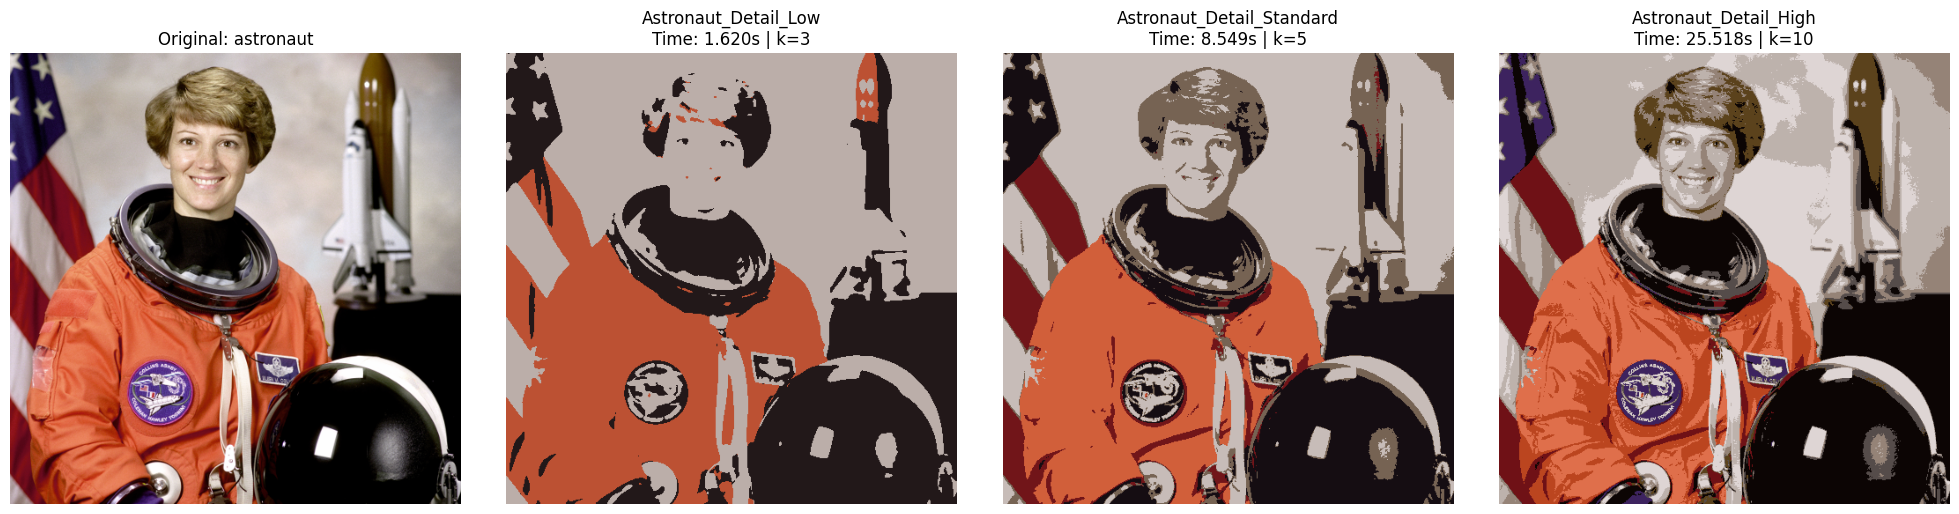

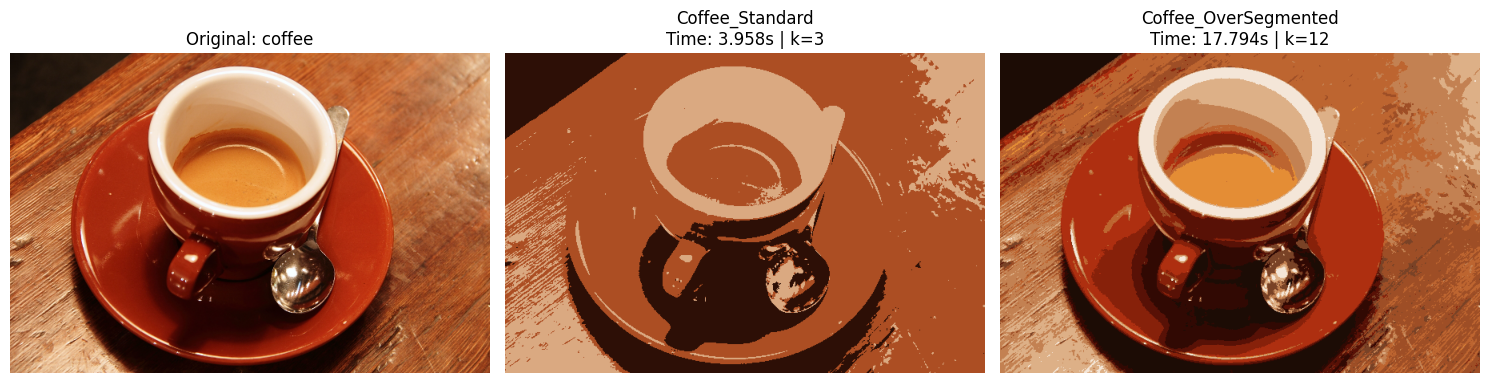

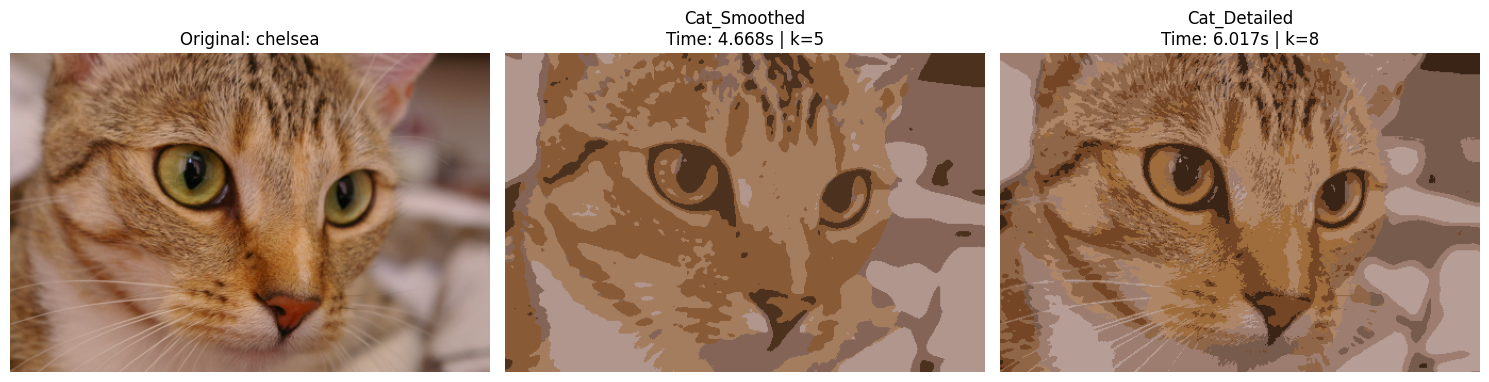

In [ ]:
"""Image segmentation experiments."""

import json
import matplotlib.pyplot as plt
from skimage import color, data
from scipy.ndimage import gaussian_filter
from qbca import QBCA
import time

# Load configs
with open('config/config_segmentation.json', 'r') as f:
    config_data = json.load(f)

# Group experiments by image_func for organized plotting
from collections import defaultdict
grouped_exps = defaultdict(list)
for exp in config_data['experiments']:
    grouped_exps[exp['image_func']].append(exp)

# Plotting: One row per image, first column is the original
for img_name, exps in grouped_exps.items():
    img_func = getattr(data, img_name)
    img = img_func()

    fig, axes = plt.subplots(1, len(exps) + 1, figsize=(5 * (len(exps) + 1), 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {img_name}")
    axes[0].axis('off')

    for j, cfg in enumerate(exps):
        # 1. Preprocessing (cite: 549)
        img_smoothed = gaussian_filter(img, sigma=(cfg['sigma'], cfg['sigma'], 0))
        img_lab = color.rgb2lab(img_smoothed)
        pixel_data = img_lab.reshape((-1, 3))

        # 2. QBCA Execution (cite: 396, 670)
        model = QBCA(k=cfg['k'], threshold=cfg['epsilon'], max_iter=cfg['max_iter'])
        start = time.time()
        labels, centers, _ = model.fit(pixel_data)
        elapsed = time.time() - start

        # 3. Reconstruction (cite: 56, 381)
        segmented_lab = centers[labels].reshape(img_lab.shape)
        segmented_rgb = color.lab2rgb(segmented_lab)

        ax = axes[j + 1]
        ax.imshow(segmented_rgb)
        ax.set_title(f"{cfg['name']}\nTime: {elapsed:.3f}s | k={cfg['k']}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
